In [38]:
%load_ext autoreload
%autoreload 2

import pickle, gzip
import numpy as np
import torch
import argparse, gzip, pickle, numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pose_utils import load_dataset_file, GROUPS, GROUP_COLORS, MSKA_KEYPOINTS, GROUPED_MSKA_KEYPOINTS, plot_confidence_distribution, EDGES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:


hrnet_data = load_dataset_file("../data/CSL-Daily.train")
rtmpose_data = load_dataset_file("../data/RTM/CSL-Daily.train")

keys = list(rtmpose_data.keys())
index = 301
sample = rtmpose_data[keys[index]]
kp = sample["keypoint"]
kp = kp.numpy() if torch.is_tensor(kp) else np.asarray(kp)
print(type(rtmpose_data))
print(f"hrnet data data len {len(hrnet_data)}")
print(f"rtmpose data data len {len(rtmpose_data)}")
print()
print(f"Sample name: {keys[index]}")
print(f"Sample keys:{list(sample.keys())}")
print(f"Sample shape: {kp.shape}")

<class 'dict'>
hrnet data data len 18401
rtmpose data data len 18400

Sample name: S000108_P0008_T00
Sample keys:['name', 'text', 'keypoint', 'gloss', 'num_frames']
Sample shape: (55, 133, 3)


In [31]:

W, H = 500, 550

def plot_frame_grouped( kp, title = "", t=0, color_by_conf=False, save=False, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8.2, 10.2))
    pts = kp[t]
    x, y, c = pts[:, 0], pts[:, 1], pts[:, 2]

    cmap = plt.cm.RdYlGn 
    active = []
    for name, idx in GROUPS.items():
        idx = np.array(idx)
        idx = idx[np.isin(idx, list(MSKA_KEYPOINTS))]
        if idx.size == 0:
            continue                
        active.append(name)

        if color_by_conf:
            ax.scatter(x[idx], y[idx], s=16, c=c[idx], cmap=cmap,
                       vmin=0, vmax=1, alpha=0.95, zorder=5)
        else:
            ax.scatter(x[idx], y[idx], s=16, color=GROUP_COLORS[name],
                       alpha=0.95, zorder=5)

        for a, b in EDGES.get(name, []):
            if a not in MSKA_KEYPOINTS or b not in MSKA_KEYPOINTS:
                continue
            if color_by_conf:
                ecol = cmap(0.5 * (c[a] + c[b]))
            else:
                ecol = GROUP_COLORS[name]
            ax.plot([x[a], x[b]], [y[a], y[b]], lw=1.2, color=ecol,
                    alpha=0.95, zorder=4)

    ax.set_xlim(50, 450); ax.set_ylim(500, 120); ax.set_aspect("equal")
    ax.set_title(f"Frame {t}/{kp.shape[0]-1} of {title}")

    if color_by_conf:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
        ax.figure.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label="Confidence")
    else:
        handles = [Line2D([0], [0], marker='o', ls='', color=GROUP_COLORS[g], label=g)
                   for g in active]
        ax.legend(handles=handles, loc="upper right", fontsize=11)

    if save:
        ax.figure.savefig(f"../latex/{title}_{'conf' if color_by_conf else 'body'}_{t}.png", dpi=300, bbox_inches="tight")
    return ax

<Axes: title={'center': 'Frame 30/54 of S000108_P0008_T00'}>

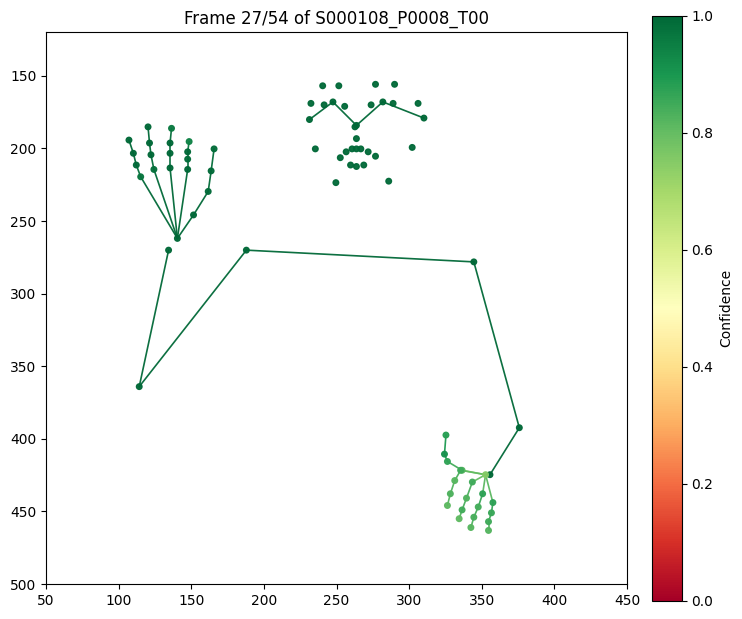

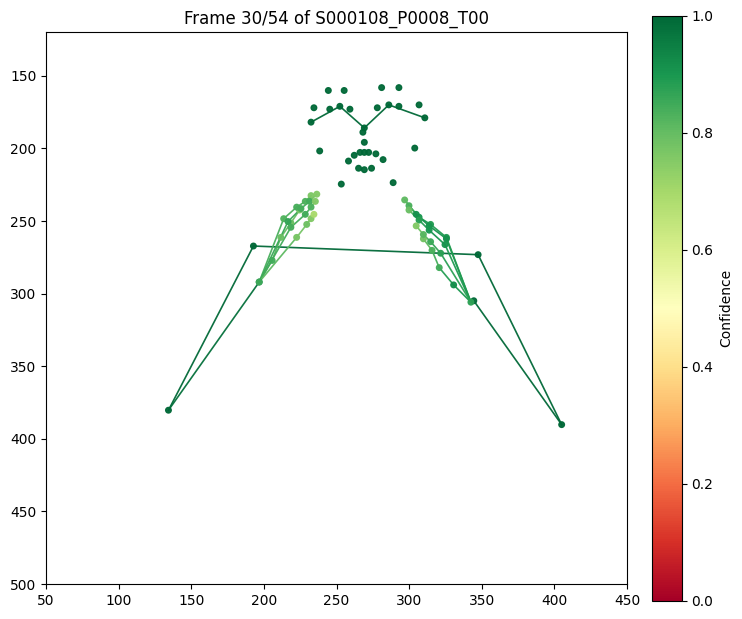

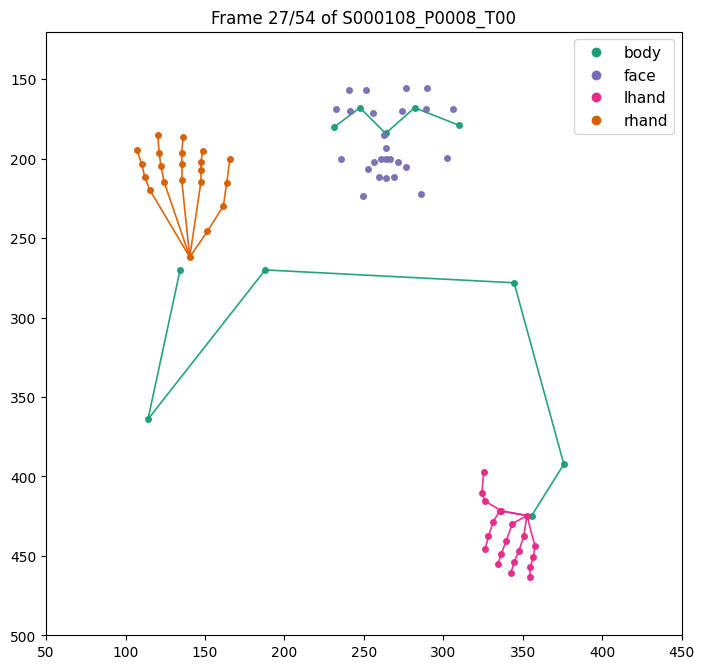

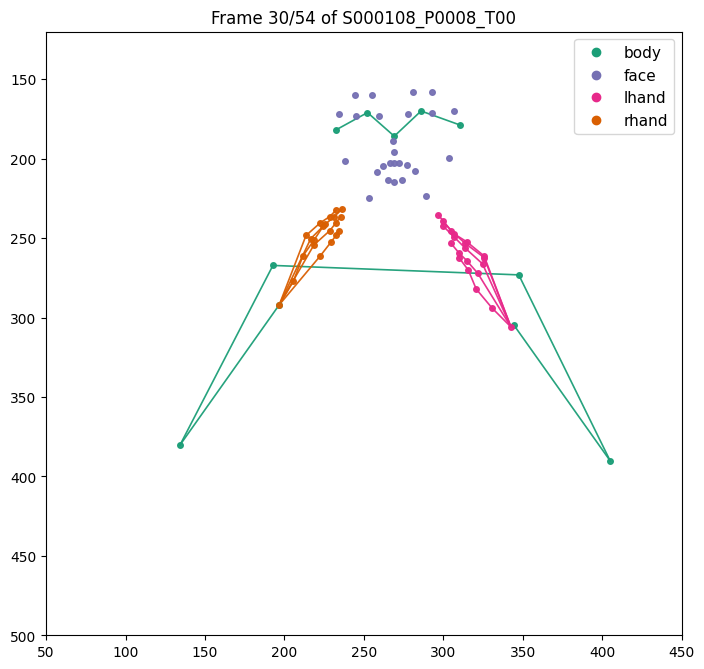

In [34]:
name = str(sample["name"])

plot_frame_grouped(kp, title=name, t=27, color_by_conf=True, save=True)
plot_frame_grouped(kp, title=name, t=30, color_by_conf=True, save=True)
plot_frame_grouped(kp, title=name, t=27, color_by_conf=False, save=True)
plot_frame_grouped(kp, title=name, t=30, color_by_conf=False, save=True)

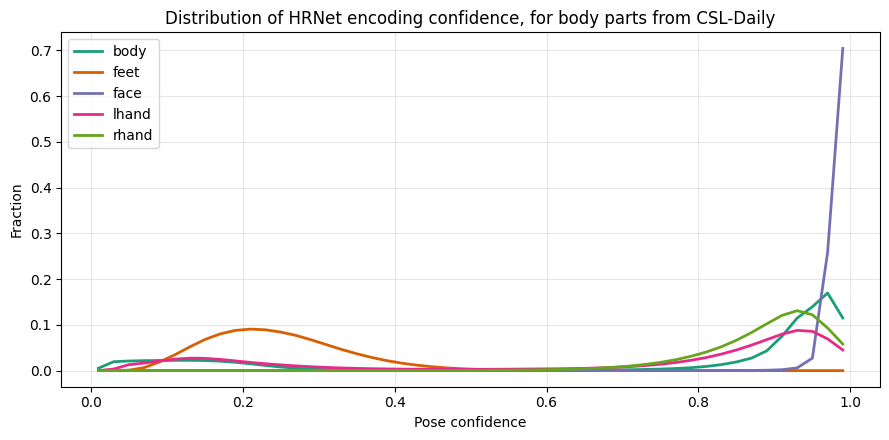

In [9]:
_, ax = plot_confidence_distribution(hrnet_data, title='Distribution of HRNet encoding confidence, for body parts from CSL-Daily')
ax.figure.savefig(f"../latex/HRNet_confidence.png", dpi=300, bbox_inches="tight")

In [51]:
keys = sorted(hrnet_data.keys() & rtmpose_data.keys())
len(keys)

rng = np.random.default_rng(0)
keys = list(rng.choice(keys, 1000, replace=False))


In [52]:
def clip_arrays(entry):
    kp = np.asarray(entry["keypoint"], np.float32)
    conf = kp[:, :, 2] if kp.shape[2] >= 3 else np.ones(kp.shape[:2], np.float32)
    return body_rel(kp[:, :, :2]), conf
    
def best_offsets(Axy, Ac, Bxy, Bc, wrists):
    Ta, Tb = Axy.shape[0], Bxy.shape[0]
    best = (np.inf, 0, 0)
    for start in OFFSETS:
        for end in OFFSETS:
            sa, sb = trim_slices(Ta, Tb, start, end)
            d = pair_dist(Axy, Ac, Bxy, Bc, sa, sb, wrists, use_conf=False)
            if not np.isnan(d) and d < best[0]:
                best = (d, start, end)
    return best

def parse_keypoints(spec):
    if not spec:
        return None
    valid = set()
    for part in spec.split(","):
        part = part.strip()
        if not part:
            continue
        if "-" in part.lstrip("-"):
            lo, hi = part.split("-")
            valid.update(range(int(lo), int(hi) + 1))
        else:
            valid.add(int(part))
    if not valid:
        raise argparse.ArgumentTypeError("empty keypoint set")
    return valid


def keep(idxs, valid):
    if valid is None:
        return list(idxs)
    return [i for i in idxs if i in valid]


def body_rel(kp):
    c = (kp[:, LSHO] + kp[:, RSHO]) / 2.0
    w = np.linalg.norm(kp[:, LSHO] - kp[:, RSHO], axis=1)
    w = w[w > 1e-6]
    s = np.clip(np.median(w) if w.size else 1.0, 1e-6, None)
    return (kp - c[:, None, :]) / s


def trim_slices(Ta, Tb, start, end):
    a0, a1, b0, b1 = 0, Ta, 0, Tb
    if start >= 0: a0 = start
    else: b0 = -start
    if end >= 0: a1 = Ta - end
    else: b1 = Tb + end
    return slice(a0, a1), slice(b0, b1)


def resample(x, L):
    return np.interp(np.linspace(0, 1, L), np.linspace(0, 1, len(x)), x)


def pair_dist(Axy, Ac, Bxy, Bc, sa, sb, idxs, use_conf):
    axy, bxy, ac, bc = Axy[sa], Bxy[sb], Ac[sa], Bc[sb]
    if axy.shape[0] < 5 or bxy.shape[0] < 5:
        return np.nan
    ds = []
    for i in idxs:
        ax, ay = resample(axy[:, i, 0], L), resample(axy[:, i, 1], L)
        bx, by = resample(bxy[:, i, 0], L), resample(bxy[:, i, 1], L)
        d = np.sqrt((ax - bx) ** 2 + (ay - by) ** 2)
        if use_conf:
            w = np.minimum(resample(ac[:, i], L), resample(bc[:, i], L))
            if w.sum() < 1e-6:
                continue
            ds.append((w * d).sum() / w.sum())
        else:
            ds.append(d.mean())
    return np.mean(ds) if ds else np.nan

In [53]:

LSHO, RSHO = 5, 6
WRISTS = [9, 10]
OFFSETS = range(-30, 31)
L = 100
valid = MSKA_KEYPOINTS
GROUPS = {"body": (0, 17), "face": (23, 91), "lhand": (91, 112), "rhand": (112, 133)}
groups = {g: keep(range(a, b), valid) for g, (a, b) in GROUPS.items()}
groups = {g: idxs for g, idxs in groups.items() if idxs}
no_conf = {g: [] for g in groups}
for k in keys:
    (Axy, Ac), (Bxy, Bc) = clip_arrays(hrnet_data[k]), clip_arrays(rtmpose_data[k])
    _, start, end = best_offsets(Axy, Ac, Bxy, Bc, WRISTS)
    sa, sb = trim_slices(Axy.shape[0], Bxy.shape[0], start, end)
    for g, idxs in groups.items():
        no_conf[g].append(pair_dist(Axy, Ac, Bxy, Bc, sa, sb, idxs, False))


print(f"{'group':<7}{'distance':>10}")
for g in groups:
    print(f"{g:<7}{np.nanmean(no_conf[g]):>10.3f}")

group    distance
body        0.033
face        0.019
lhand       0.252
rhand       0.100


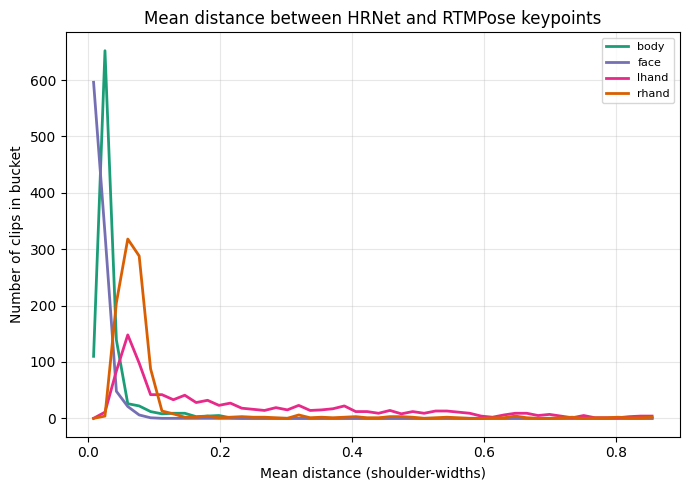